# 02 · Resultados de la CNN 1-D de referencia (Ciclo 2)

Este notebook **no entrena**: lee lo que produjo `uv run python -m qcnn_ecg.experimentos`
(`results/cnn/`) y lo presenta para el informe.

**Protocolo final**
1. Datos: conjunto `mitdb_binario_v1` (notebook 01). DS1 (22 pacientes) para desarrollo y DS2 sin el 202 (21 pacientes) para la prueba.
2. Ablación de 6 variantes con **validación cruzada de 5 pliegues por paciente** dentro de DS1 (semilla 0). Cada variante se mide con las predicciones fuera de pliegue (OOF) de los 22 pacientes.
3. La mejor variante fija su **umbral** (máximo F1 en OOF) y su **número de épocas** (mediana de los pliegues). Después se entrena con todo DS1 con 3 semillas.
4. Cada modelo final se evalúa **una sola vez** en prueba.

In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

from qcnn_ecg import config

DIR = config.DIR_RESULTADOS / "cnn"
resumen = pd.read_csv(DIR / "resumen.csv")
final = json.loads((config.DIR_MODELOS / "cnn1d_final.json").read_text(encoding="utf-8"))
variante = final["variante"]
print(f"Variante elegida: {variante} | umbral {final['umbral']:.4f} | épocas {final['epocas']}")

Variante elegida: base | umbral 0.6150 | épocas 3


## 1. Ablación: F1 fuera de pliegue frente al número de parámetros

,variante,parametros,minutos,epocas_final,umbral,oof_f1,oof_sensibilidad,oof_especificidad,oof_auc_pr
0,base,11265,11.7766,3,0.6150,0.7320,0.7361,0.9068,0.6646
1,kiranyaz,9605,8.4217,3,0.3976,0.6968,0.7942,0.8355,0.6647
2,flatten,82945,17.4538,6,0.2528,0.6931,0.8395,0.8024,0.7017
3,dropout_05,11265,9.0377,3,0.4860,0.6447,0.6793,0.8550,0.5984
4,kernels_grandes,22657,20.3102,5,0.1793,0.6257,0.7794,0.7588,0.5687
5,filtros_x2,39873,32.7914,4,0.7987,0.6192,0.6087,0.8789,0.5398


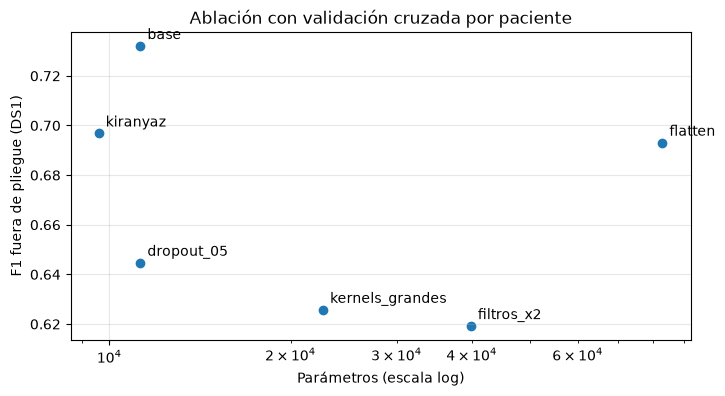

In [2]:
cv = resumen[resumen.fase == "cv"].sort_values("oof_f1", ascending=False)
display(cv[["variante", "parametros", "minutos", "epocas_final", "umbral", "oof_f1",
            "oof_sensibilidad", "oof_especificidad", "oof_auc_pr"]].round(4).reset_index(drop=True))

fig, eje = plt.subplots(figsize=(8, 4))
eje.scatter(cv.parametros, cv.oof_f1)
for _, f in cv.iterrows():
    eje.annotate(f.variante, (f.parametros, f.oof_f1), textcoords="offset points", xytext=(5, 5))
eje.set(xscale="log", xlabel="Parámetros (escala log)", ylabel="F1 fuera de pliegue (DS1)",
        title="Ablación con validación cruzada por paciente")
eje.grid(alpha=0.3)
plt.show()

## 2. Variabilidad entre pacientes

F1 de la variante elegida en cada pliegue (umbral propio del pliegue). La dispersión muestra cuánto depende el desempeño de *quién* es el paciente.

In [3]:
metricas_cv = json.loads((DIR / "cv" / f"{variante}_s0" / "metricas_cv.json").read_text(encoding="utf-8"))
display(pd.DataFrame(metricas_cv["pliegues"]).round(3))
display(Markdown("**Acierto por tipo de latido (OOF en DS1):**"))
display(pd.DataFrame(metricas_cv["oof_por_simbolo"]).T.round(3))

,pliegue,registros,latidos,epocas,mejor_epoca,f1_umbral_propio,umbral_propio,auc_pr
0,0,"[119, 203, 208, 215, 223]",13879,8,3,0.678,0.522,0.668
1,1,"[112, 124, 201, 209]",9122,8,3,0.409,0.001,0.288
2,2,"[101, 109, 115, 230]",8599,8,3,0.950,0.615,0.960
3,3,"[106, 108, 116, 205, 207]",10714,8,3,0.733,0.591,0.663
4,4,"[114, 118, 122, 220]",8676,12,7,0.947,0.427,0.984


**Acierto por tipo de latido (OOF en DS1):**

,n,acierto
N,38085.0,0.907
L,3947.0,0.976
R,3780.0,0.522
V,3683.0,0.895
A,810.0,0.285
F,414.0,0.087
E,105.0,0.714
a,100.0,0.380
J,32.0,0.000
e,16.0,0.000


## 3. Curvas de entrenamiento por pliegue (variante elegida)

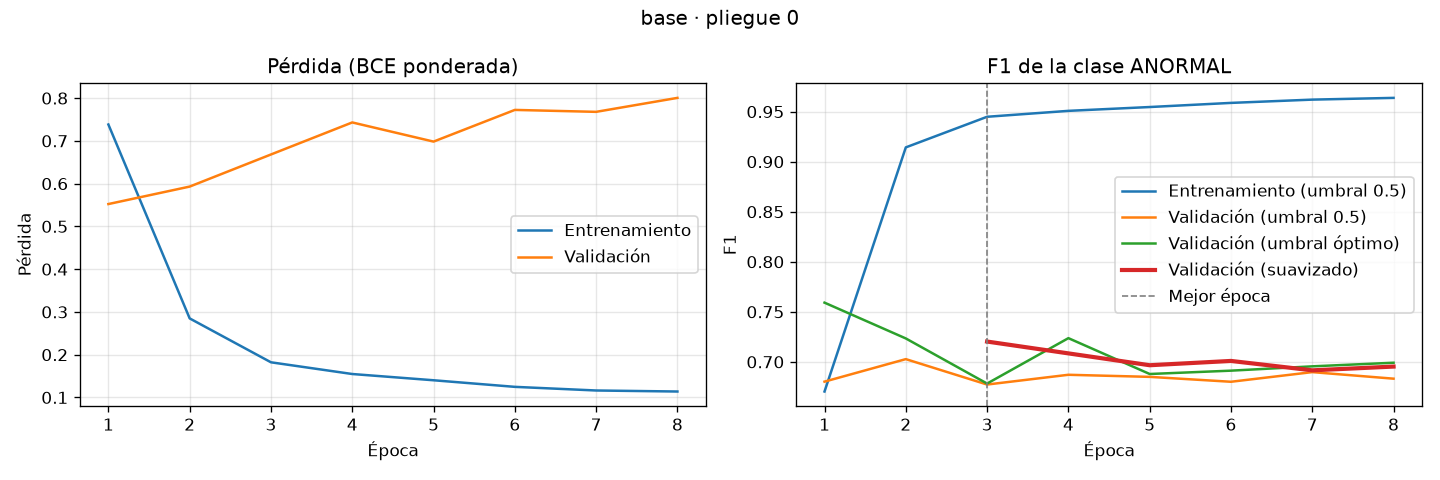

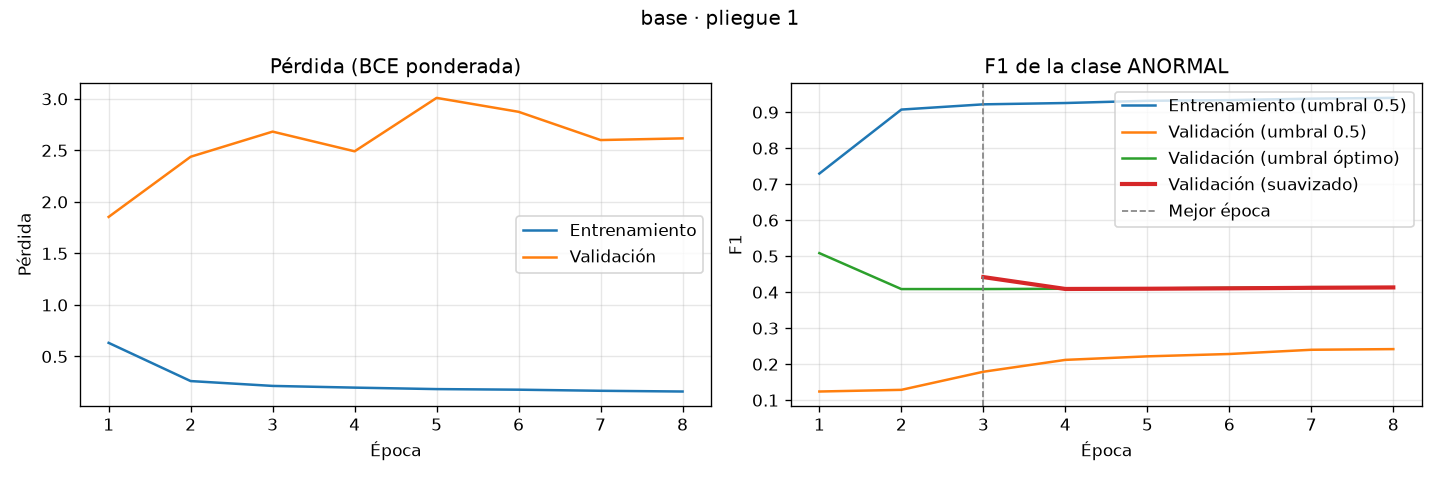

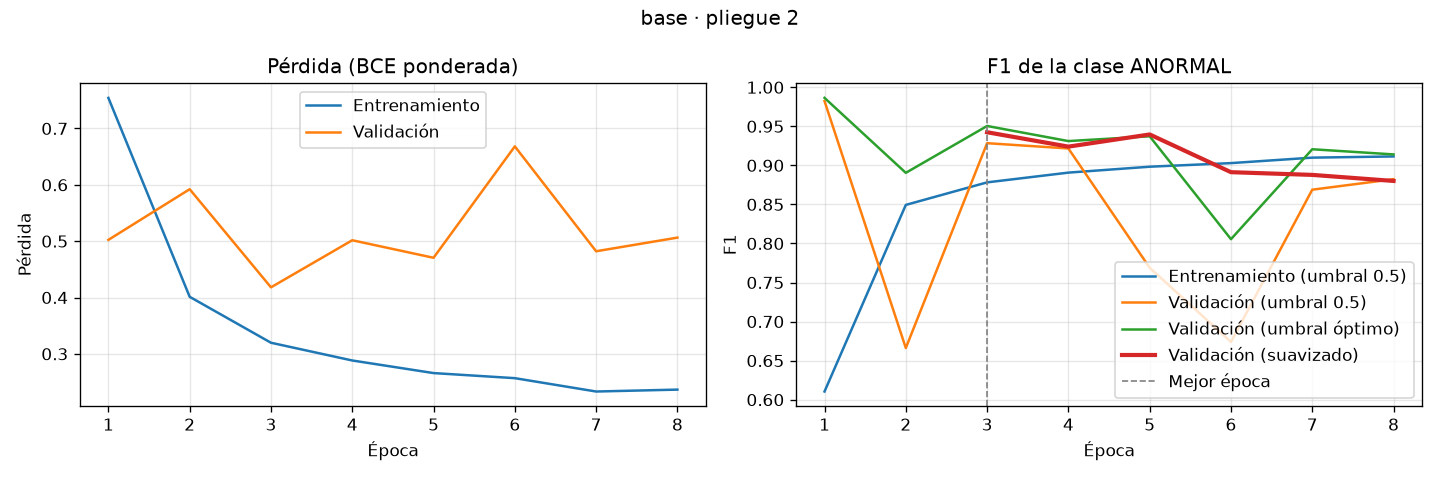

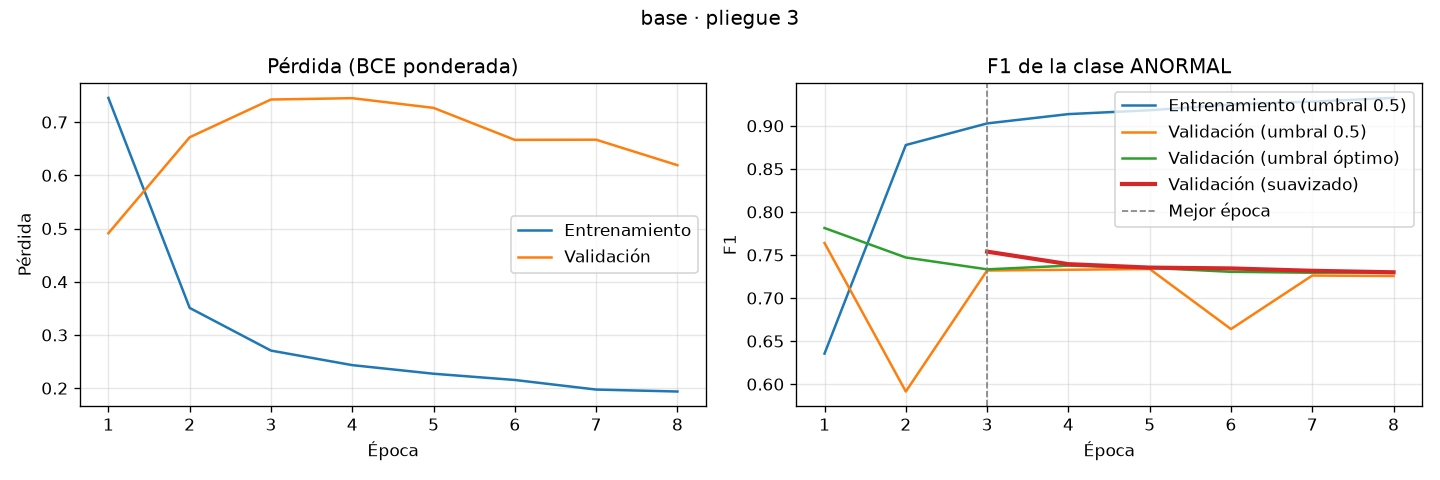

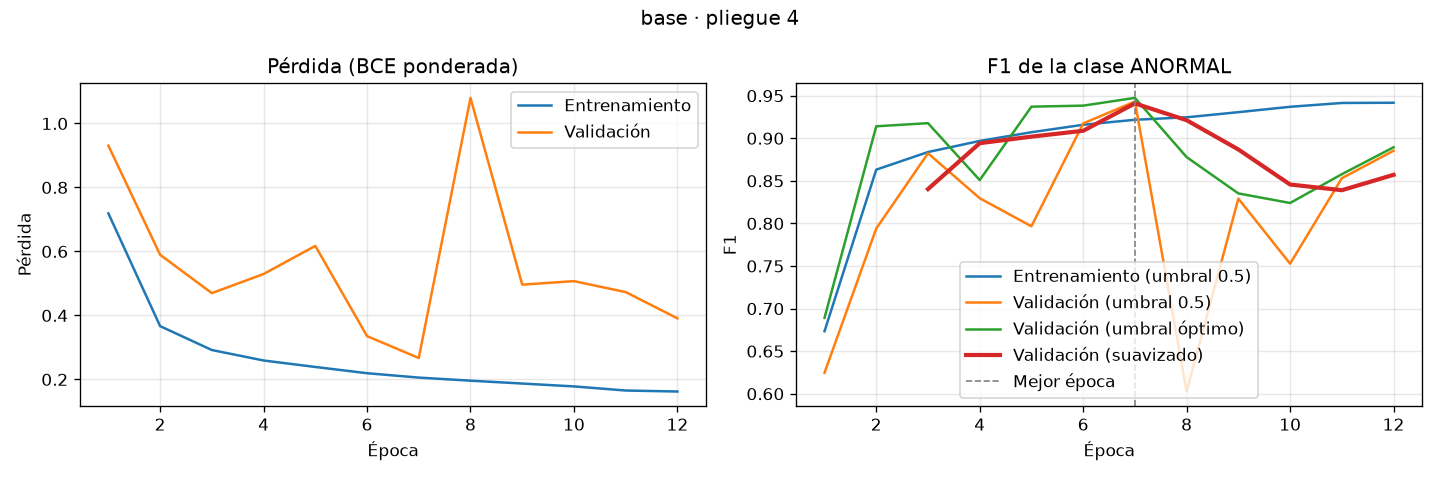

In [4]:
for k in range(5):
    display(Image(DIR / "cv" / f"{variante}_s0" / f"curvas_pliegue{k}.png"))

## 4. Resultados en prueba (DS2 sin 202) y con el 202 incluido

In [5]:
texto = (DIR / "resumen.md").read_text(encoding="utf-8")
display(Markdown("## Prueba" + texto.split("## Prueba", 1)[1]))

## Prueba: variante `base`, media ± desviación de 3 semillas

Umbral fijado con la CV en DS1: **0.6150**. Épocas del modelo final: **3**. La prueba se evaluó una sola vez por semilla.

| Métrica | DS2 sin 202 (principal) | DS2 con 202 (comparable con la literatura) |
| :--- | ---: | ---: |
| exactitud | 0.7869 ± 0.0496 | 0.7899 ± 0.0551 |
| precision | 0.6854 ± 0.1622 | 0.6785 ± 0.1682 |
| sensibilidad | 0.6097 ± 0.2291 | 0.6096 ± 0.2292 |
| especificidad | 0.8548 ± 0.1542 | 0.8555 ± 0.1563 |
| f1 | 0.6058 ± 0.0469 | 0.6012 ± 0.0434 |
| f1_macro | 0.7271 ± 0.0225 | 0.7266 ± 0.0256 |
| auc_roc | 0.8397 ± 0.0271 | 0.8409 ± 0.0260 |
| auc_pr | 0.6780 ± 0.0194 | 0.6728 ± 0.0179 |

### Matriz de confusión en prueba por semilla ([[VN, FP], [FN, VP]])

- Semilla 0: `[[33203, 1163], [7712, 5470]]`
- Semilla 1: `[[23330, 11036], [1817, 11365]]`
- Semilla 2: `[[31597, 2769], [5906, 7276]]`

### Acierto por tipo de latido

Para `N` equivale a la especificidad; para los demás, a su sensibilidad.

| Símbolo | Latidos en prueba | Acierto en prueba | Acierto OOF en DS1 |
| :--- | ---: | ---: | ---: |
| N | 34,366 | 0.8548 ± 0.1542 | 0.9068 |
| L | 4,124 | 0.4044 ± 0.3311 | 0.9759 |
| R | 3,475 | 0.7855 ± 0.1792 | 0.5217 |
| V | 3,200 | 0.9019 ± 0.0690 | 0.8947 |
| A | 1,700 | 0.3002 ± 0.4202 | 0.2852 |
| F | 387 | 0.3979 ± 0.2682 | 0.0870 |
| j | 213 | 0.3599 ± 0.1583 | 0.0625 |
| J | 51 | 0.0392 ± 0.0340 | 0.0000 |
| a | 31 | 0.3441 ± 0.2781 | 0.3800 |
| E | 1 | 0.0000 ± 0.0000 | 0.7143 |

### Costo

- Parámetros: 11,265
- Entrenamiento final por semilla: 0.87 ± 0.01 min
- Latencia por latido (lote de 1): mediana 0.892 ± 0.149 ms; p95 2.388 ± 1.835 ms
- Throughput (lotes de 256): 9463 ± 1725 latidos/s

Modelo para el prototipo: semilla 0 (por convención; las semillas finales no tienen validación propia para elegir entre ellas), copiado a `modelos_entrenados/cnn1d_final.pt`.

La corrida anterior con un único pliegue de validación (5 pacientes) está en `results/cnn_pliegue_unico/`: allí el umbral elegido (≈ 0.997) no se trasladó a la prueba (F1 0.29 con AUC-ROC 0.90), lo que motivó este protocolo.


## 5. Matrices de confusión y curvas ROC / precisión-sensibilidad en prueba

**base_s0**

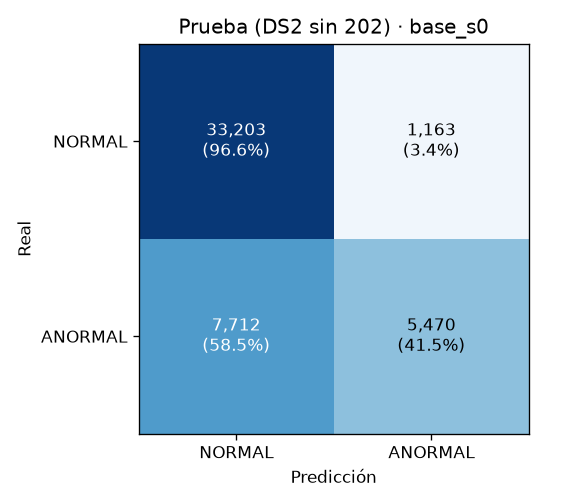

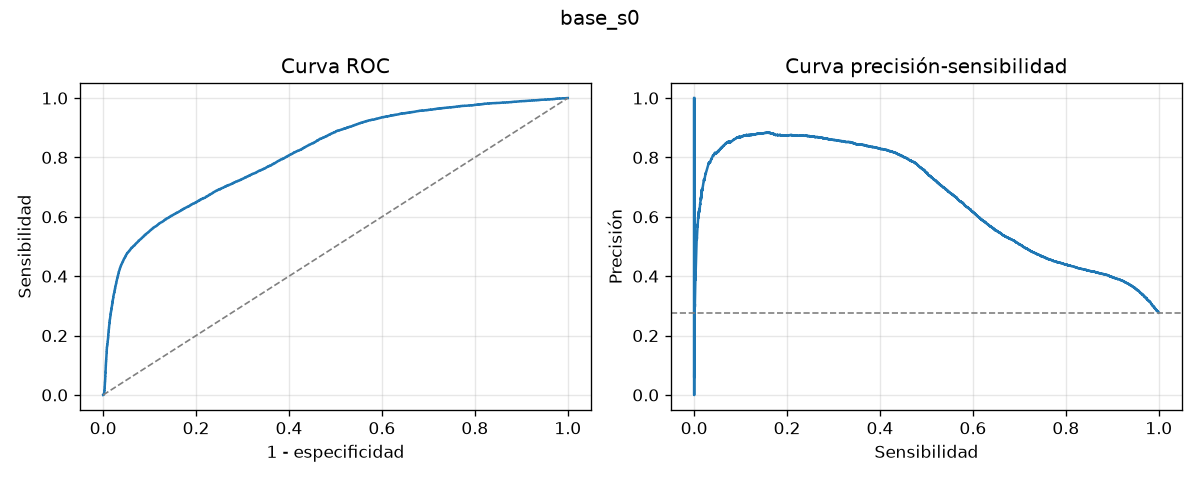

**base_s1**

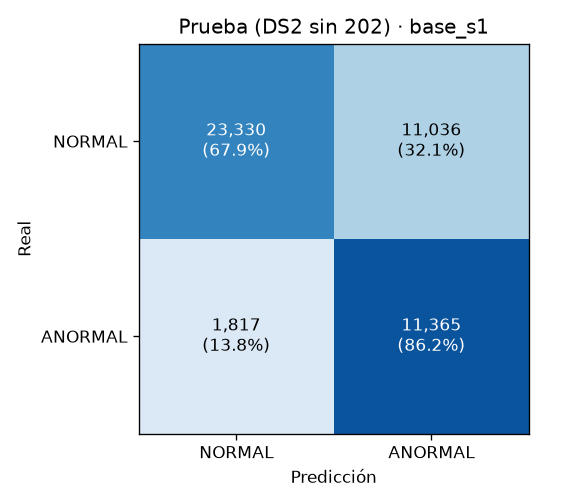

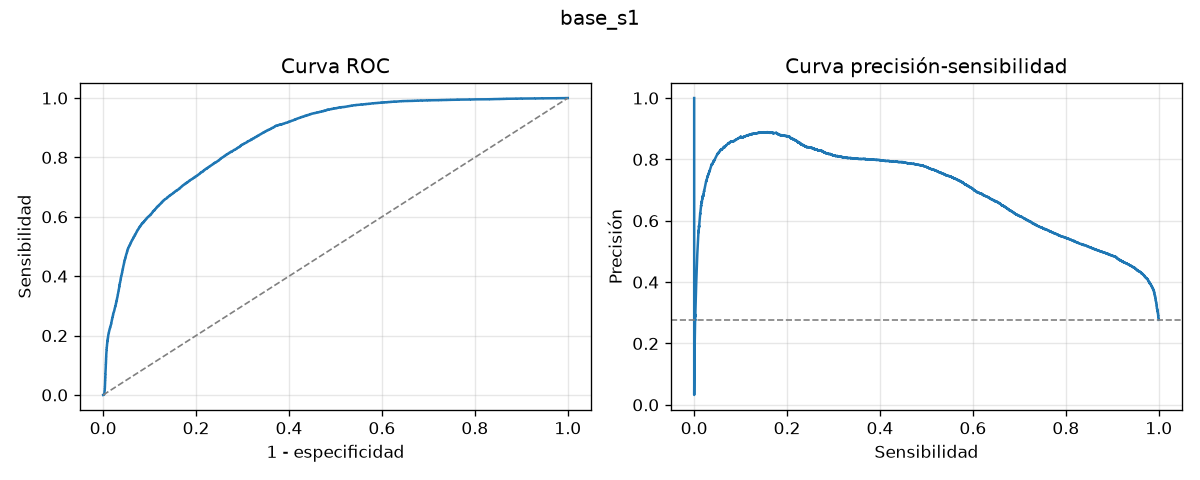

**base_s2**

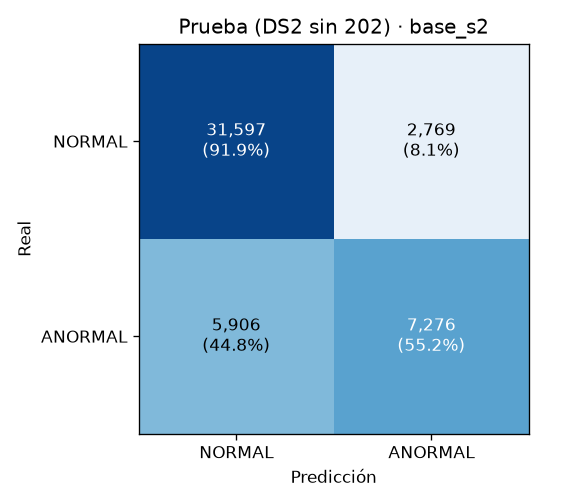

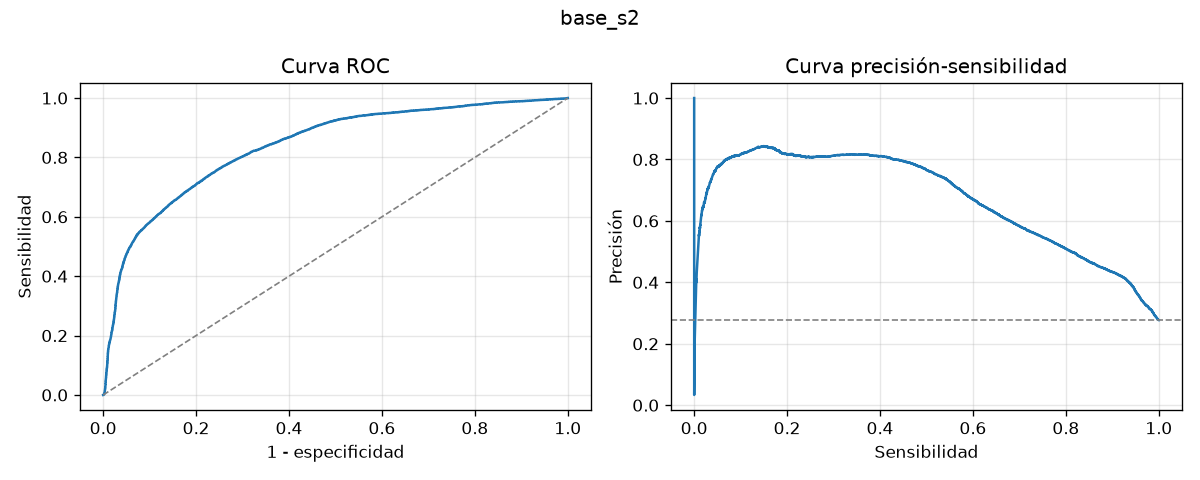

In [6]:
for carpeta in sorted((DIR / "final").glob(f"{variante}_s*")):
    display(Markdown(f"**{carpeta.name}**"))
    display(Image(carpeta / "matriz_confusion_prueba.png"))
    display(Image(carpeta / "roc_pr_prueba.png"))

## 6. Por qué se cambió el protocolo: validación con un solo pliegue

La primera corrida (`results/cnn_pliegue_unico/`) validó con solo 5 pacientes. El 56 % de los latidos anormales de esa validación eran los `L` del registro 207. La variante y el umbral elegidos (≈ 0.997) no se trasladaron a pacientes nuevos.

In [7]:
unico = pd.read_csv(config.DIR_RESULTADOS / "cnn_pliegue_unico" / "resumen.csv")
finales_unico = unico[unico.prueba_f1.notna()] if "prueba_f1" in unico else unico.iloc[0:0]
comparacion = pd.DataFrame({
    "protocolo": ["un pliegue (5 pacientes)", "validación cruzada (22 pacientes)"],
    "F1 prueba": [finales_unico.prueba_f1.mean(), resumen[resumen.fase == "final"].prueba_f1.mean()],
    "AUC-ROC prueba": [finales_unico.prueba_auc_roc.mean(), resumen[resumen.fase == "final"].prueba_auc_roc.mean()],
})
comparacion.round(3)

,protocolo,F1 prueba,AUC-ROC prueba
0,un pliegue (5 pacientes),0.289,0.897
1,validación cruzada (22 pacientes),0.606,0.840


## 7. Lectura de los resultados

- **Desempeño de referencia**: la CNN `base` (11 mil parámetros) alcanza en prueba un F1 de la clase anormal de alrededor de 0.61 y un AUC-ROC de alrededor de 0.84 sobre pacientes que nunca vio. Es el número contra el que se comparará la QCNN.
- **Dónde acierta y dónde falla**: detecta bien las contracciones ventriculares (`V`) y los bloqueos de rama derecha (`R`). Falla en los prematuros auriculares (`A`), que se distinguen por el ritmo y no por la forma: la CNN solo ve la morfología de 0.8 s. Los `L` dependen mucho del paciente.
- **Variabilidad entre semillas**: el modelo final entrena solo 3 épocas (la red se especializa pronto en los pacientes de entrenamiento). Por eso la semilla cambia bastante el balance entre sensibilidad y especificidad, aunque el F1 se mantiene. Hay que reportar siempre la media ± desviación.
- **Variabilidad entre pacientes**: el F1 por pliegue va de 0.4 a 0.95. La generalización a personas nuevas es el reto central de MIT-BIH entre pacientes.
- **Para la QCNN (Ciclo 3)**: debe usar `qcnn_ecg.conjunto.cargar_conjunto()`, la misma partición y los mismos pliegues (`qcnn_ecg.particion.pliegues_ds1`), las funciones de `qcnn_ecg.evaluacion` y este mismo protocolo de umbral y semillas.
- **Limitaciones**: filtro `filtfilt` no causal (análisis offline). El 202 se excluye de la prueba por ser la misma persona que el 201. La CV de la ablación usa una sola semilla.